# Natural Language Processing: Text Preprocessing and Vectorisation

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook demonstrates fundamental NLP preprocessing techniques for text data. It covers regular expression‑based information extraction (emails, phone numbers), lemmatisation and stemming (English and Spanish), and vectorisation using CountVectorizer. These techniques form the foundation for text classification, clustering, and information retrieval tasks.

**Key techniques & libraries:**
- Regular expressions (`re`) – pattern matching and extraction
- NLTK – WordNet lemmatiser, Snowball stemmer, stopwords
- spaCy – Spanish lemmatisation (es_core_news_sm)
- Scikit‑learn – `CountVectorizer` for bag‑of‑words representation

**Data source:**  
Sample text corpus embedded in the notebook – no external files required.

In [2]:
!python -m spacy download es_core_news_sm

     ---------------------------------------- 12.9/12.9 MB 375.4 kB/s  0:00:38
[+] Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [3]:
# Imports and configuration
import re
import nltk
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# Reproducibility seeds
np.random.seed(42)

# Download required NLTK data (only if not already present)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Load Spanish spaCy model (assumes it's installed)
nlp = spacy.load("es_core_news_sm")

# Matplotlib style
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\phabe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\phabe\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
def extract_emails(text):
    """
    Extract email addresses from text using regex.
    
    Args:
        text (str): Input text.
    
    Returns:
        list: List of extracted email strings.
    """
    pattern = r'[\w\.-]+@[\w\.-]+'
    return re.findall(pattern, text)

def extract_phone_numbers(text, pattern=r'\b\d{10}\b'):
    """
    Extract phone numbers matching a pattern (default: 10 digits).
    
    Args:
        text (str): Input text.
        pattern (str): Regex pattern for phone numbers.
    
    Returns:
        list: List of matched phone number strings.
    """
    return re.findall(pattern, text)

def lemmatize_english(words, pos='v'):
    """
    Lemmatise a list of English words using WordNet lemmatiser.
    
    Args:
        words (list): List of words.
        pos (str): Part-of-speech tag (default: 'v' for verb).
    
    Returns:
        list: Lemmatised words.
    """
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word, pos=pos) for word in words]

def lemmatize_spanish(text):
    """
    Lemmatise Spanish text using spaCy.
    
    Args:
        text (str): Spanish text.
    
    Returns:
        list: Lemmatised tokens (lemmas).
    """
    doc = nlp(text)
    return [token.lemma_ for token in doc]

def stem_spanish(words):
    """
    Apply Snowball stemmer to Spanish words.
    
    Args:
        words (list): List of Spanish words.
    
    Returns:
        list: Stemmed words.
    """
    stemmer = SnowballStemmer("spanish")
    return [stemmer.stem(word) for word in words]

def tokenize_and_vectorize(corpus, **vectorizer_kwargs):
    """
    Convert a corpus of text documents into a bag‑of‑words matrix.
    
    Args:
        corpus (list): List of text documents.
        **vectorizer_kwargs: Additional arguments for CountVectorizer.
    
    Returns:
        tuple: (X, vectorizer) where X is the document‑term matrix and vectorizer is the fitted CountVectorizer.
    """
    vectorizer = CountVectorizer(**vectorizer_kwargs)
    X = vectorizer.fit_transform(corpus)
    return X, vectorizer

def display_vectorizer_results(X, vectorizer, feature_names=None):
    """
    Display the document‑term matrix and feature names.
    
    Args:
        X (sparse matrix): Document‑term matrix from CountVectorizer.
        vectorizer (CountVectorizer): Fitted vectorizer.
        feature_names (list, optional): Custom feature names; if None, use vectorizer.get_feature_names_out().
    """
    if feature_names is None:
        feature_names = vectorizer.get_feature_names_out()
    df = pd.DataFrame(X.toarray(), columns=feature_names)
    print("Document‑Term Matrix:")
    display(df)
    print(f"Total features: {len(feature_names)}")

## 1. Regular Expressions for Information Extraction

Regular expressions (regex) are powerful tools for extracting structured information from unstructured text. We demonstrate extraction of email addresses and phone numbers.

In [5]:
# Sample text with emails and a phone number
sample_text = (
    "It is only with the heart that one can see rightly; "
    "what is essential is invisible to the eye. "
    "And my email is djikstra08@gmail.com; my cellphone number is 5534823204. "
    "126gywbq. iorveth@yahoo.com"
)

# Extract emails
emails = extract_emails(sample_text)
print("Extracted emails:", emails)

# Extract phone numbers (10 digits)
phones = extract_phone_numbers(sample_text)
print("Extracted phone numbers:", phones)

Extracted emails: ['djikstra08@gmail.com', 'iorveth@yahoo.com']
Extracted phone numbers: ['5534823204']


## 2. Lemmatisation and Stemming

**Lemmatisation** reduces words to their dictionary form (lemma) using vocabulary and morphological analysis. **Stemming** is a simpler rule‑based process that chops off word endings to produce a root form (stem).

We demonstrate both in English and Spanish.

In [6]:
# English words
english_words = ["running", "ran", "run", "studies", "holding", "loved"]

# Lemmatise (using verb POS to get base form)
lemmas_en = lemmatize_english(english_words, pos='v')
print("Original words:", english_words)
print("Lemmatised (English):", lemmas_en)

Original words: ['running', 'ran', 'run', 'studies', 'holding', 'loved']
Lemmatised (English): ['run', 'run', 'run', 'study', 'hold', 'love']


In [7]:
# Spanish words
spanish_words = ["corriendo", "correr", "corre", "corrió", "corremos", "corren", "corredor", "corredizo"]

# Lemmatisation with spaCy
spanish_text = " ".join(spanish_words)
lemmas_es = lemmatize_spanish(spanish_text)
print("Spanish lemmas (spaCy):", lemmas_es)

# Stemming with Snowball
stems_es = stem_spanish(spanish_words)
print("Spanish stems (Snowball):", stems_es)

Spanish lemmas (spaCy): ['correr', 'correr', 'correr', 'correr', 'corremo', 'correr', 'corredor', 'corredizo']
Spanish stems (Snowball): ['corr', 'corr', 'corr', 'corr', 'corr', 'corr', 'corredor', 'corrediz']


## 3. Tokenisation and Vectorisation

To use text in machine learning, we convert documents into numerical feature vectors. **CountVectorizer** creates a bag‑of‑words representation: each document is represented by the frequency of each word in the vocabulary.

We demonstrate on a small corpus of famous quotes.

In [8]:
# Example corpus
corpus = [
    "Live life like its the last breath you take for that breath is the whole essence of living, the little things in life are what connects us to all the big things we live for",
    "It is only with the heart that one can see rightly",
    "There is some good in this world, and it’s worth fighting for.",
    "In three words I can sum up everything I've learned about life: it goes on."
]

# Vectorise with default parameters (includes stopwords, punctuation)
X, vectorizer = tokenize_and_vectorize(corpus)
display_vectorizer_results(X, vectorizer)

# Optional: Remove English stopwords for a cleaner representation
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
X_clean, vectorizer_clean = tokenize_and_vectorize(corpus, stop_words=stop_words)
print("\nAfter removing stopwords:")
display_vectorizer_results(X_clean, vectorizer_clean)

Document‑Term Matrix:


,about,all,and,are,big,breath,can,connects,essence,everything,...,us,ve,we,what,whole,with,words,world,worth,you
0,0,1,0,1,1,2,0,1,1,0,...,1,0,1,1,1,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,1,0,0,0,0,0,1,0,0,1,...,0,1,0,0,0,0,1,0,0,0


Total features: 53

After removing stopwords:
Document‑Term Matrix:


,big,breath,connects,essence,everything,fighting,goes,good,heart,last,...,see,sum,take,things,three,us,whole,words,world,worth
0,1,2,1,1,0,0,0,0,0,1,...,0,0,1,2,0,1,1,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0,0,0,0,1,0,1,0,0,0,...,0,1,0,0,1,0,0,1,0,0


Total features: 28


### Visualising Term Frequencies

We can visualise the distribution of term frequencies across documents using a heatmap.

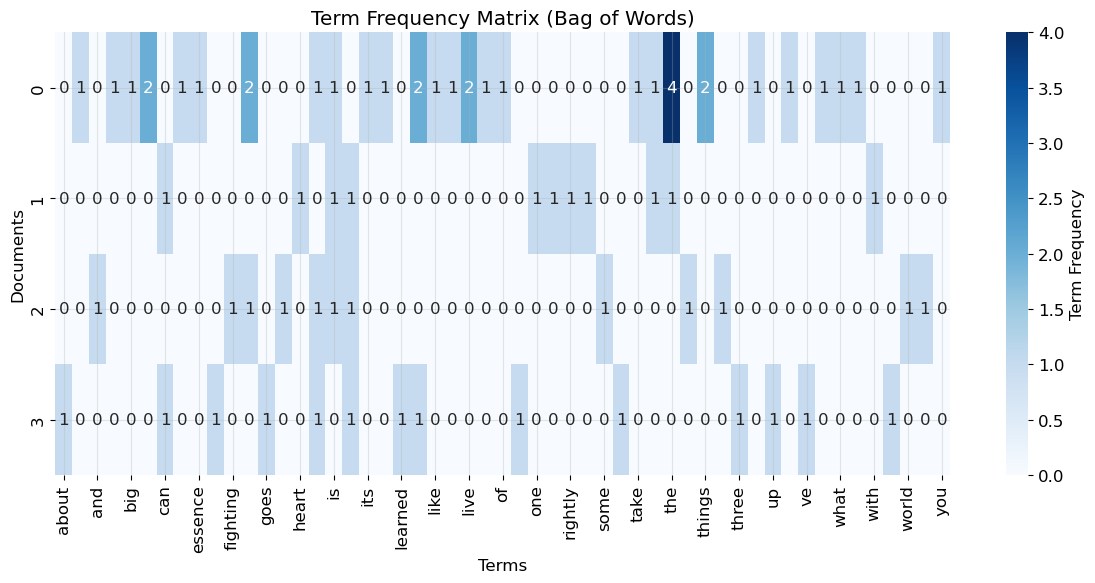

In [9]:
# Convert to DataFrame and plot heatmap
import seaborn as sns

df_viz = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
plt.figure(figsize=(12, 6))
sns.heatmap(df_viz, annot=True, cmap='Blues', cbar_kws={'label': 'Term Frequency'})
plt.title('Term Frequency Matrix (Bag of Words)')
plt.xlabel('Terms')
plt.ylabel('Documents')
plt.tight_layout()
plt.show()

## Summary and Next Steps

**Accomplished in this notebook:**

- Demonstrated regex‑based extraction of emails and phone numbers.
- Applied lemmatisation in English (WordNet) and Spanish (spaCy).
- Applied stemming in Spanish (Snowball stemmer).
- Converted text documents into bag‑of‑words vectors using CountVectorizer.
- Visualised term frequencies across documents.

**Key insights:**

- Lemmatisation produces dictionary forms and is more linguistically accurate than stemming.
- Stemming is faster but can produce non‑word roots.
- CountVectorizer provides a simple but effective text representation for many tasks.
- Removing stopwords can reduce noise and improve model performance.

**Suggested next steps (critical thinking):**

1. **Advanced vectorisation** – experiment with TF‑IDF (`TfidfVectorizer`) to weight terms by inverse document frequency.
2. **N‑gram features** – include bigrams or trigrams to capture phrase context using `ngram_range`.
3. **Topic modelling** – apply LDA (Latent Dirichlet Allocation) to discover latent topics in a larger corpus.
4. **Word embeddings** – explore pre‑trained embeddings (Word2Vec, GloVe) for semantic representation.
5. **Custom preprocessing pipelines** – wrap lemmatisation, stopword removal, and vectorisation into a `Pipeline` for production use.

This notebook provides a solid foundation for NLP preprocessing and feature extraction.